In [2]:
import xarray as xr
import tifffile
import numpy as np
import glob, os, gc
import pandas as pd
import scanpy as sc
import vima

Assumption is that each dataset that comes with cells has them in AnnData format with the following fields:

* d.X - raw markers pre-standardization/normalization/log-transform
* d.obs - a column named sid and an index named cid. It can optionally also have a column named celltype.
* d.obsm['spatial'] - 2D array with x- and y-coordinates in microns

# Define functions

In [3]:
import re

# write multi-channel tiff for CANVAS
def prep_canvas(datadir, outpath, channel_selector=None):
    print("Preparing data for CANVAS")
    
    files = glob.glob(f'{datadir}/10u/counts/*.nc')
    outdir = f'{outpath}/canvas/data/raw_data'
    os.makedirs(f'{outdir}', exist_ok=True)  
    os.makedirs(f'{outdir}/image_files', exist_ok=True)
    os.makedirs(f'{outdir}/../../configs/preprocess', exist_ok=True)

    for f in files:
        name = os.path.splitext(os.path.basename(f))[0].replace('.', '-')
        d = xr.open_dataarray(f)
        if channel_selector is not None:
            selected_markers = [m for m in d.marker.values if channel_selector.match(m)]
            print(f'filtered markers, now {len(selected_markers)} markers remain')
        d = d.sel(marker=selected_markers)
        avgchannel = d.mean(dim="marker")
        avg_channel_expanded = avgchannel.expand_dims(dim={"marker": ["avg"]})
        d = xr.concat([d, avg_channel_expanded], dim="marker")

        # Save marker values to a text file
        with open(f"{outdir}/image_files/{name}.txt", "w") as txt_file:
            for marker in d.marker.values:
                txt_file.write(f"{marker}\n")

        # Save as a multi-channel TIFF
        arr = d.values  # shape (Y, X, channel)
        arr_tiff = np.transpose(arr, (2, 0, 1))  # shape (channel, Y, X)
        tifffile.imwrite(f"{outdir}/image_files/{name}.tif", arr_tiff)

    infile = glob.glob(f'{outdir}/image_files/*.txt')[0]
    outfile1 = f'{outdir}/common_channels.txt'
    outfile2 = f'{outdir}/../../configs/preprocess/channels_vis_strength.yaml'

    with open(infile, "r") as infile, open(outfile1, "w") as of1, open(outfile2, "w") as of2:
        for line in infile:
            of1.write(line)
            of2.write(line.strip() + ": 1\n")

    print('Remember to manually place a config.yaml file in the canvas/configs directory.')
    print('and to manually place a selected_channels_w_color.yaml file in the canvas/configs/preprocess directory.')

In [68]:
# cells files for UTAG, CellCharter, and TissueMosaic
def prep_cells(cellspath, outpath, celltypesfile=None, celltypesname=None, leidenres=0.375):
    print("Preparing Cells file")
    d = sc.read(cellspath)
    d.write(f'{outpath}/cells_counts.h5ad')

    sc.pp.normalize_total(d, target_sum=np.median(d.X.sum(axis=1)))
    sc.pp.log1p(d)
    sc.tl.pca(d)
    allcells_pca = d.obs
    pcs = [f'PC{i+1}' for i in range(d.obsm['X_pca'].shape[1])]
    for pc, col in zip(pcs, d.obsm['X_pca'].T):
        allcells_pca[pc] = col
    harmpcs = vima.pp.harmonize(allcells_pca, '/Users/yakir/miniconda3/envs/Renv/bin/Rscript')
    d.obsm['X_pca'] = harmpcs[pcs].values
    d.write(f'{outpath}/cells_normalized_harm.h5ad')

    if 'celltype' in d.obs.columns:
        print('cell types already in dataset')
    elif celltypesfile is not None:
        print('adding cell types from external file')
        types = pd.read_csv(celltypesfile, sep='\t', index_col=0)
        d.obs['celltype'] = types[celltypesname]
        d = d[~d.obs.celltype.isna()]
    else:
        sc.pp.neighbors(d)
        sc.tl.leiden(d, resolution=leidenres, key_added='celltype')
    print(len(d), 'typed cells')
    d.write(f'{outpath}/cells_normalized_harm_typed.h5ad')

In [69]:
# 100u spots file for STAGATE
def prep_spots100u(datadir, filename_parser, outpath):
    print("Preparing Spots file")
    
    # read in data and make into visium-sized spots
    files = glob.glob(f'{datadir}/10u/counts/*.nc')

    def downsample(data, sid, donor):
        y, x, c = data.shape
        new_y, new_x = y // 10, x // 10
        downsampled = data.data[:new_y * 10, :new_x * 10, :].reshape(new_y, 10, new_x, 10, c).sum(axis=(1, 3))
        y_coords = data.coords['y'][np.arange(0, new_y*10, 10)]
        x_coords = data.coords['x'][np.arange(0, new_x*10, 10)]
        
        downsampled = downsampled.reshape(-1, c)
        df = pd.DataFrame(downsampled, columns=data.coords['marker'].values)
        df['y_microns'] = np.repeat(y_coords, new_x)
        df['x_microns'] = np.tile(x_coords, new_y)
        df['sid'] = sid
        df['donor'] = donor
        return df

    samples = []
    for f in files:
        print('.', end='')
        s = xr.open_dataarray(f).astype(np.float32)
        s.attrs.update(filename_parser(f))
        samples.append(downsample(s, s.attrs['sid'], s.attrs['donor']))
    gc.collect()

    samples = pd.concat(samples)
    probes = samples.columns[:-4]
    genes = [g for g in probes if 'Blank' not in g]
    metadata = ['sid','donor', 'x_microns','y_microns']
    samples = samples[metadata + genes]

    # remove spots with few transcripts
    samples = samples[samples[genes].sum(axis=1) >= 500]
    samples.reset_index(inplace=True, drop=True)

    # create anndata object
    d = sc.AnnData(X=samples[genes],
                obs=samples[metadata],
                var=pd.DataFrame(index=genes))
    d.obsm['spatial'] = samples[['x_microns','y_microns']].values
    d.uns['spatial'] = samples[['x_microns','y_microns']].values

    # qc
    sc.pp.normalize_total(d, target_sum=np.median(d.X.sum(axis=1)))
    sc.pp.log1p(d)

    #save
    d.write(f'{outpath}/100u_spots.h5ad')

In [85]:
# create patch-level average metamarker profile and cell type abundance profile
def add_cellcounts(d, cells):
    for sid in d.obs.sid.unique():
        print(sid, end='|')
        mycells = cells[cells.obs.sid == sid]
        mycellscoords = mycells.obsm['spatial']
        mypatches = d.obs[d.obs.sid == sid]
        cellcounts = pd.concat([
                mycells[(mycellscoords[:,0] >= x)&(mycellscoords[:,0] <= x+10*ps)&
                        (mycellscoords[:,1] >= y)&(mycellscoords[:,1] <= y+10*ps)].obs.celltype.value_counts()
                for x,y,ps in mypatches[['x_microns','y_microns', 'patchsize']].values
            ], axis=1).T.fillna(0)
        columns = cellcounts.columns.values
        d.obs.loc[d.obs.sid == sid, columns] = cellcounts.values
    d.obs['totalcells'] = d.obs[columns].sum(axis=1).values
    d.uns['celltypes'] = columns

def prep_patch_reps(datadir, filename_parser, outpath, repname='pca_k=10_harmony', cellspath=None):
    # read in samples
    samples = vima.read_samples(f'{datadir}/10u/{repname}/*.nc', filename_parser)

    # create patches
    P = vima.PatchCollection(samples) # this line may not be needed
    Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
    print(len(Pdense), 'dense patches')

    # create avg meta-marker profiles
    Pdense.numpy_mode()
    d = sc.AnnData(
        X=Pdense[:][0].mean(axis=(1,2)),
        obs=Pdense.meta)
    sc.pp.neighbors(d, use_rep='X')
    sc.tl.umap(d)
    sc.tl.leiden(d, resolution=1, key_added='leiden1')
    d.write(f'{outpath}/patches_avgmm.h5ad')
    print('done creating avg mm profiles')

    # create cell type abundance profiles
    if cellspath is not None:
        cells = sc.read(cellspath)

        add_cellcounts(d, cells)
        d = sc.AnnData(
            X=np.nan_to_num(d.obs[d.uns['celltypes']].values / d.obs.totalcells.values[:,None]),
            obs=d.obs,
            var=pd.DataFrame(index=pd.Series(d.uns['celltypes'], name='celltype')))
        sc.pp.neighbors(d, use_rep='X')
        sc.tl.umap(d)
        sc.tl.leiden(d, resolution=1, key_added='leiden1')
        d.write(f'{outpath}/patches_celltypeabundance.h5ad')

# Run

## ALZ

In [2]:
def alz_filename_parser(fname):
    fname = os.path.splitext(os.path.basename(fname))[0]
    return {
        'donor': fname.split('_')[0],
        'sid': fname.split('_')[1]
    }
    
datadir = '../../ALZ/alz-data'
outpath = '_data/ALZ'

In [ ]:
prep_cells(f'{datadir}/SEAAD_MTG_MERFISH.2024-12-11.filtered.h5ad', outpath,
           celltypesfile=f'{datadir}/SEAAD_MTG_MERFISH_metadata.2024-05-03.noblanks.harmonized.formatted.txt',
           celltypesname='subclass_name')


In [5]:
prep_canvas(datadir, outpath)

Preparing data for CANVAS
Remember to manually place a config.yaml file in the canvas/configs directory.


In [51]:
prep_spots100u(datadir, alz_filename_parser, outpath)

Preparing Spots file
...........................................................................

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [66]:
prep_patch_reps(datadir, alz_filename_parser,
                outpath,
                cellspath=f'{outpath}/cells_normalized_harm_typed.h5ad')

100%|███████████████████████████████████████████████████████████████| 75/75 [00:22<00:00,  3.32it/s]


in pytorch mode
means: [ 0.03098334  0.01770616  0.00883776  0.01203802  0.06749605 -0.03304671
 -0.00347992 -0.04077578  0.01343075 -0.00886017]
stds: [1.4058533  1.2035424  1.0260984  0.9526732  0.87071246 0.8799561
 0.923573   0.7982908  0.77537245 0.7527368 ]
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 75/75 [00:11<00:00,  6.72it/s]


in pytorch mode
means: [ 0.26597616  0.01684863 -0.02094653  0.08868911  0.08523259 -0.03306107
  0.03388684 -0.06028556  0.00141709 -0.00657909]
stds: [1.4910085  1.3239772  1.158306   1.0947176  0.99781376 1.0068313
 1.018981   0.92427564 0.88088864 0.88987595]
data augmentation is off
70898 dense patches
data augmentation is off
in numpy mode


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


1217500814|1185930850|1195928136|1217500810|1192523789|1185930845|1217501029|1296199308|1175046730|1175046724|1116997297|1217500871|1194111812|1296199271|1217501462|1217499825|1174511279|1217499815|1172983297|1194111462|1217499820|1194111807|1182389655|1217501042|1218552402|1217501037|1194113131|1162693722|1162693732|1176833749|1182389662|1296510469|1172983307|1176833728|1176833739|1162693727|1296199281|1192523794|1175046718|1238559483|1218552485|1296199314|1218552298|1193169898|1296199276|1218552100|1172983302|1218552293|1217500876|1218552479|1296510477|1174511271|1195928141|1217500590|1174511265|1218552392|1217500806|1217500585|1182389669|1218552275|1196150174|1218552387|

## UC

In [4]:
def uc_fname_parser(fname): 
    fname = fname.split("/")[-1].split(".nc")[0]
    if fname[-1].islower():
        donor = fname[:-1]
    else: 
        donor = fname
    return {'sid': fname, 'donor': donor}
datadir = '../../UC/UC-data'
outpath = '_data/UC'

Preparing Cells file
=== running harmony ===


Loading required package: Rcpp
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)
code for methods in class “Rcpp_harmony” was not checked for suspicious field assignments (recommended package ‘codetools’ not available?)

Attaching package: ‘arrow’

The following object is masked from ‘package:utils’:

    timestamp



harmonizing
metadata names: sid 


Transposing data matrix
Initializing state using k-means centroids initialization
Harmony 1/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 2/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Harmony 3/10
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|---

writing  /var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/tmptzkasi06_harmony.feather 
=== finished running harmony ===


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


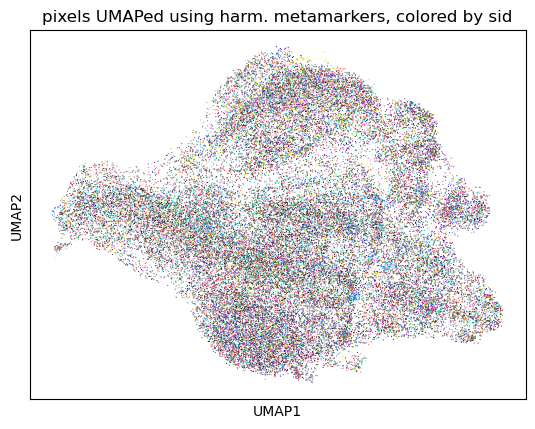

cell types already in dataset
1647673 typed cells


In [77]:
prep_cells(f'{datadir}/IBD_CODEX_190825_k100_nc14_Cells.filtered_typed.h5ad', outpath)

In [5]:
channel_selector = re.compile(r'^(?!.*(blank|HOECHST|HOCHST|empty)).*$', re.IGNORECASE) # filter out blank channels (since empty) and HOECHST channels (since batchy)
prep_canvas(datadir, outpath, channel_selector=channel_selector)

Preparing data for CANVAS
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered markers, now 53 markers remain
filtered marke

In [79]:
prep_spots100u(datadir, uc_fname_parser, outpath)

Preparing Spots file
..........................................

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [87]:
prep_patch_reps(datadir, uc_fname_parser,
                outpath,
                cellspath=f'{outpath}/cells_normalized_harm_typed.h5ad')

100%|███████████████████████████████████████████████████████████████| 42/42 [00:03<00:00, 12.34it/s]


in pytorch mode
means: [ 0.10416102  0.0328236  -0.01539228 -0.05839088 -0.05421956  0.00433612
  0.0087974  -0.09060202  0.01675035  0.04969878]
stds: [2.7762876  1.6164097  1.5301462  0.98550224 0.7064669  0.6947279
 0.85681367 0.70924395 0.85073173 0.7015509 ]
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 14.75it/s]


in pytorch mode
means: [ 0.08237299  0.012785   -0.0340474  -0.06955624 -0.0628859  -0.00149565
  0.01077035 -0.10602376  0.00874131  0.04395426]
stds: [2.9123013  1.713814   1.6145148  1.0410776  0.7507728  0.737872
 0.9015797  0.7511908  0.889453   0.74117184]
data augmentation is off
21359 dense patches
data augmentation is off
in numpy mode


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


done creating avg mm profiles
HC3|UC19|UC29|UC28|UC18|UC13b|UC5|UC27|HC2a|UC23a|UC1|UC4a|UC17|UC14b|UC22|UC16b|UC2a|UC12|UC26|UC3|UC4c|UC14a|UC21|UC15|UC16a|UC2b|UC7|UC11|UC25|UC13a|UC6|UC10|UC24|HC2b|UC23b|UC4b|UC20|UC9|HC5|HC1|UC8|HC4|

/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_96014/2529230679.py:44: RuntimeWarning: invalid value encountered in divide
  X=np.nan_to_num(d.obs[d.uns['celltypes']].values / d.obs.totalcells.values[:,None]),


## RA

In [88]:
def ra_fname_parser(fname):
    fname = os.path.splitext(os.path.basename(fname))[0]
    return {
        'donor': fname.split('_')[0].replace('Repeat',''),
        'sid': fname
    }
datadir = '../../RA/BHAM-data'
outpath = '_data/RA'
repname = 'pca_k=5_harmony'

In [82]:
prep_canvas(datadir, outpath)

Preparing data for CANVAS


In [83]:
prep_spots100u(datadir, ra_fname_parser, outpath)

Preparing Spots file
...........................

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [89]:
prep_patch_reps(datadir, ra_fname_parser,
                outpath,
                repname=repname)

100%|███████████████████████████████████████████████████████████████| 27/27 [00:07<00:00,  3.46it/s]


in pytorch mode
means: [-0.05322419 -0.03296076 -0.00334196 -0.02602021  0.00115104]
stds: [0.79031086 0.7810323  0.7555943  0.52936673 0.39200044]
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 27/27 [00:05<00:00,  4.82it/s]


in pytorch mode
means: [-0.05159876 -0.01707248  0.05088576 -0.01906051  0.00809487]
stds: [0.91344094 0.9179958  0.8742071  0.6127676  0.46941248]
data augmentation is off
22497 dense patches
data augmentation is off
in numpy mode


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


done creating avg mm profiles
